Number of real samples: 400
Bin spacing without zero-padding: 40.0 Hz
Bin spacing with zero-padding: 7.8125 Hz
Peak without zero-padding: 440.0 Hz
Peak with zero-padding: 437.5 Hz


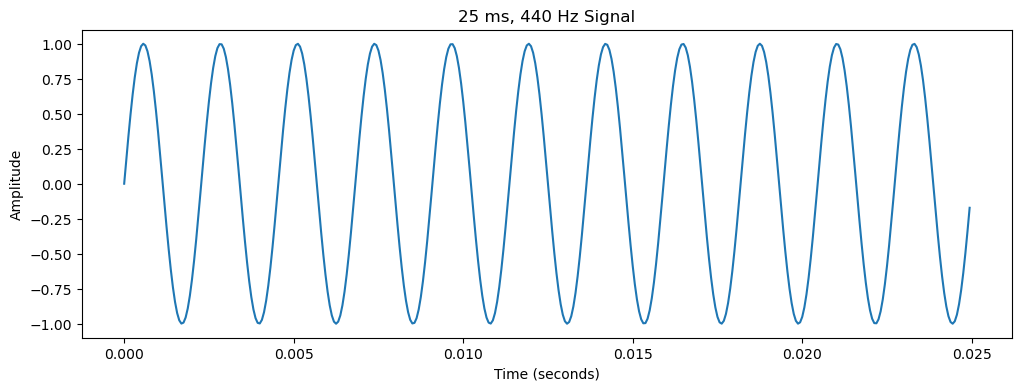

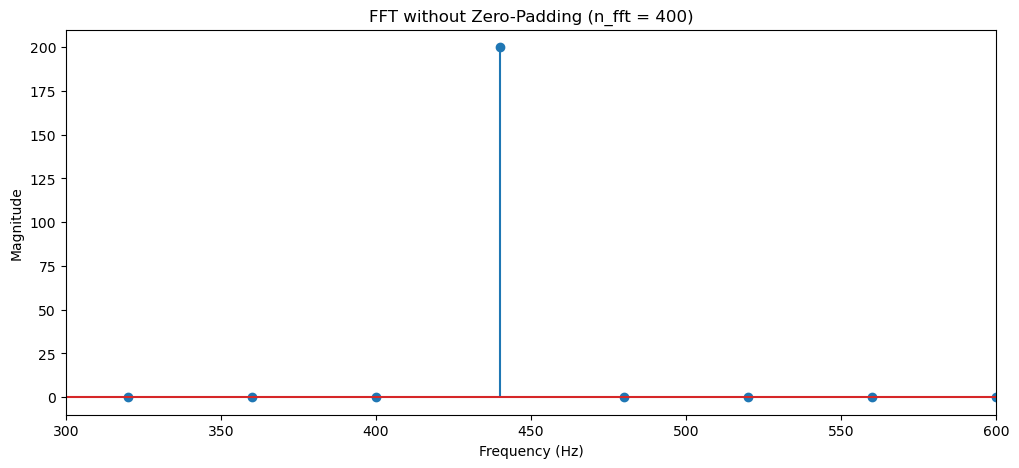

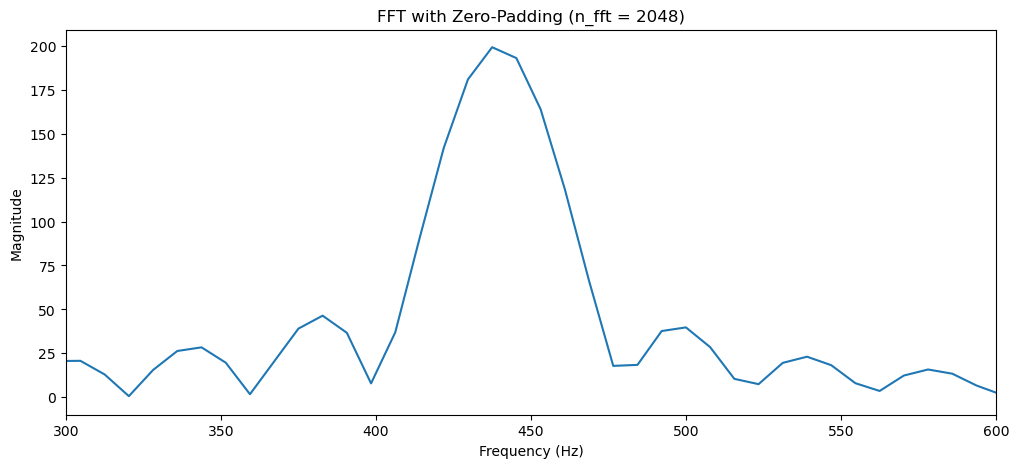

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Create a short synthetic signal
# --------------------------------------------------

sample_rate = 16000
duration = 0.025          # 25 ms
frequency = 440           # 440 Hz tone

N = int(sample_rate * duration)

time = np.arange(N) / sample_rate

signal = np.sin(
    2 * np.pi * frequency * time
)

print("Number of real samples:", N)

# --------------------------------------------------
# 2. FFT without zero-padding
# --------------------------------------------------

n_fft_1 = N               # 400

spectrum_1 = np.fft.rfft(
    signal,
    n=n_fft_1
)

freqs_1 = np.fft.rfftfreq(
    n_fft_1,
    d=1 / sample_rate
)

magnitude_1 = np.abs(spectrum_1)

print(
    "Bin spacing without zero-padding:",
    sample_rate / n_fft_1,
    "Hz"
)

# --------------------------------------------------
# 3. FFT with zero-padding
# --------------------------------------------------

n_fft_2 = 2048

spectrum_2 = np.fft.rfft(
    signal,
    n=n_fft_2
)

freqs_2 = np.fft.rfftfreq(
    n_fft_2,
    d=1 / sample_rate
)

magnitude_2 = np.abs(spectrum_2)

print(
    "Bin spacing with zero-padding:",
    sample_rate / n_fft_2,
    "Hz"
)

# --------------------------------------------------
# 4. Find strongest FFT bin in both cases
# --------------------------------------------------

peak_index_1 = np.argmax(magnitude_1)
peak_frequency_1 = freqs_1[peak_index_1]

peak_index_2 = np.argmax(magnitude_2)
peak_frequency_2 = freqs_2[peak_index_2]

print(
    "Peak without zero-padding:",
    peak_frequency_1,
    "Hz"
)

print(
    "Peak with zero-padding:",
    peak_frequency_2,
    "Hz"
)

# --------------------------------------------------
# 5. Plot original signal
# --------------------------------------------------

plt.figure(figsize=(12, 4))

plt.plot(
    time,
    signal
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("25 ms, 440 Hz Signal")

plt.show()

# --------------------------------------------------
# 6. Plot FFT without zero-padding
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.stem(
    freqs_1,
    magnitude_1
)

plt.xlim(300, 600)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(
    "FFT without Zero-Padding (n_fft = 400)"
)

plt.show()

# --------------------------------------------------
# 7. Plot FFT with zero-padding
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    freqs_2,
    magnitude_2
)

plt.xlim(300, 600)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(
    "FFT with Zero-Padding (n_fft = 2048)"
)

plt.show()